In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

In [2]:
from google.colab import files
uploaded = files.upload()

Saving ALMdata.mat to ALMdata.mat


In [3]:
matdat = loadmat('/content/ALMdata.mat')

In [17]:
matdat

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Tue Jul 21 07:38:12 2020',
 '__version__': '1.0',
 '__globals__': [],
 'Channel_all': array([[ 1],
        [11],
        [14],
        ...,
        [13],
        [13],
        [14]], dtype=uint8),
 'PSTH_nonprefer_cue_aligned': array([[ 0.11764706,  0.11764706,  0.11764706, ...,  3.76470588,
          3.64705882,  3.76470588],
        [ 0.0862069 ,  0.0862069 ,  0.0862069 , ...,  0.0862069 ,
          0.0862069 ,  0.0862069 ],
        [ 0.        ,  0.        ,  0.        , ...,  0.4       ,
          0.4       ,  0.4       ],
        ...,
        [ 1.53846154,  1.53846154,  1.53846154, ...,  2.15384615,
          2.15384615,  2.15384615],
        [11.16438356, 11.30136986, 11.36986301, ..., 18.42465753,
         18.42465753, 18.49315068],
        [ 3.45238095,  3.51190476,  3.51190476, ...,  2.38095238,
          2.5       ,  2.55952381]]),
 'PSTH_prefer_cue_aligned': array([[ 0.        ,  0.        ,  0.        , ..

In [18]:
NOT_PREFERENCE = matdat['PSTH_nonprefer_cue_aligned']
PREFERENCE = matdat['PSTH_prefer_cue_aligned']
TIME = matdat['t'][0]
CHANNEL_INDEX = matdat['Channel_all']

print(NOT_PREFERENCE.shape), print(' ')
print(PREFERENCE.shape), print(' ')
print(TIME.shape), print(' ')
CHANNEL_INDEX = CHANNEL_INDEX.flatten()
print(CHANNEL_INDEX.shape), print(' ')

(1186, 5101)
 
(1186, 5101)
 
(5101,)
 
(1186,)
 


(None, None)

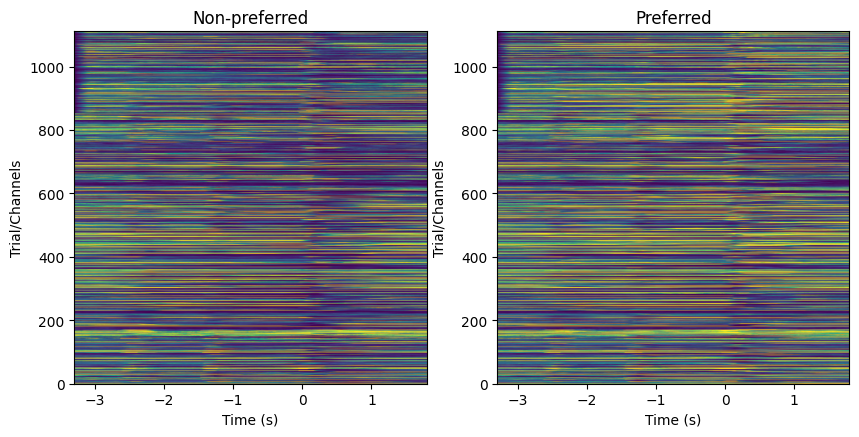

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))

ax[0].imshow(NOT_PREFERENCE, extent=[TIME[0], TIME[-1], 0, NOT_PREFERENCE.shape[0]],
             vmin=0, vmax=10, origin='upper')
ax[0].set_aspect(1/ax[0].get_data_ratio())
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Trial/Channels')
ax[0].set_title('Non-preferred')

ax[1].imshow(PREFERENCE, extent=[TIME[0], TIME[-1], 0, PREFERENCE.shape[0]],
             vmin=0, vmax=10, origin='upper')
ax[1].set_aspect(1/ax[1].get_data_ratio())
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Trial/Channels')
ax[1].set_title('Preferred')
plt.show()

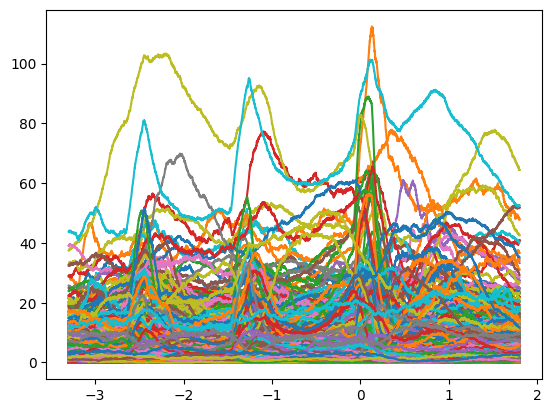

In [24]:
plt.plot(TIME, NOT_PREFERENCE.T)
plt.show()

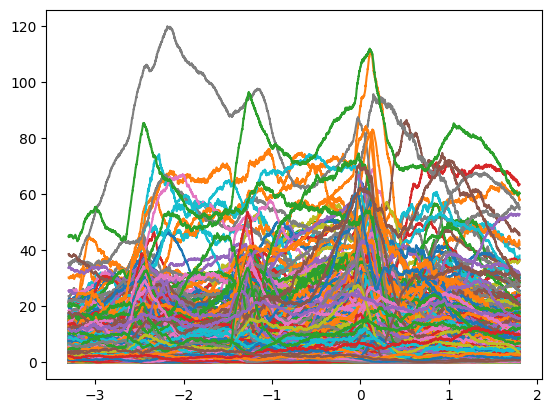

In [21]:
plt.plot(TIME, PREFERENCE.T)
plt.show()


In [22]:
NOT_PREFERENCE = NOT_PREFERENCE[np.isfinite(NOT_PREFERENCE[:,0]),:]
CHANNEL_INDEX = CHANNEL_INDEX[np.isfinite(PREFERENCE[:,0])]
PREFERENCE = PREFERENCE[np.isfinite(PREFERENCE[:,0]),:]


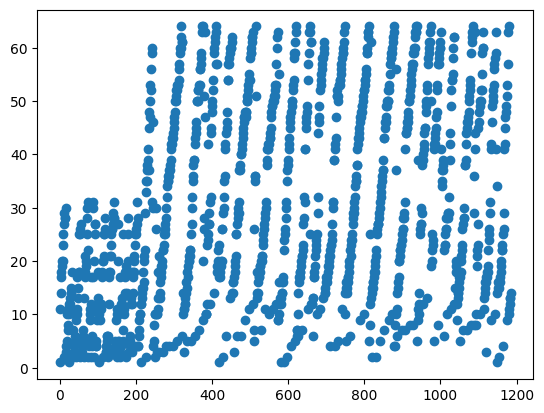

In [14]:
plt.plot(CHANNEL_INDEX, 'o')

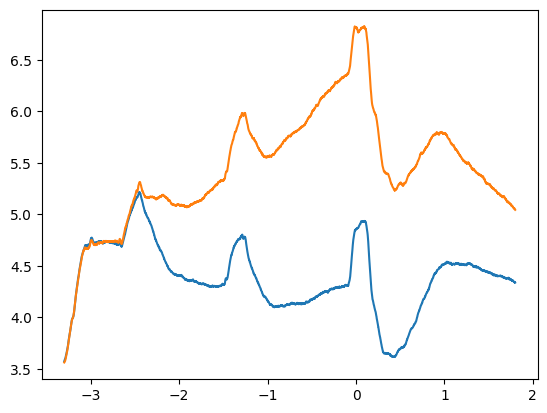

In [26]:
plt.plot(TIME, np.mean(NOT_PREFERENCE, axis=0), label='Non Preference')
plt.plot(TIME, np.mean(PREFERENCE, axis=0), label='Preference')
plt.show()